# DeepSeek-V4.1-Flash (EXL3 3.0 bpw) on 4× CMP 170HX: TP4 + EP4, all experts in VRAM, DSpark

| Metric (measured, served configuration) | Value |
|---|---:|
| Decode, 1 user: structured / code / prose (tok/s) | **98.4 / 79.3 / 26–38** |
| Decode, 4 users aggregate: structured / code / prose (tok/s) | **220.9 / 143.3 / 85.0** |
| Prefill, 7k–51k prompt tokens, Engram tables not cached | **475–791 tok/s** |
| Known-answer checks | 5 / 5 |
| Edit reply (4,720 tokens), identical with and without the drafter | 49.5 tok/s |

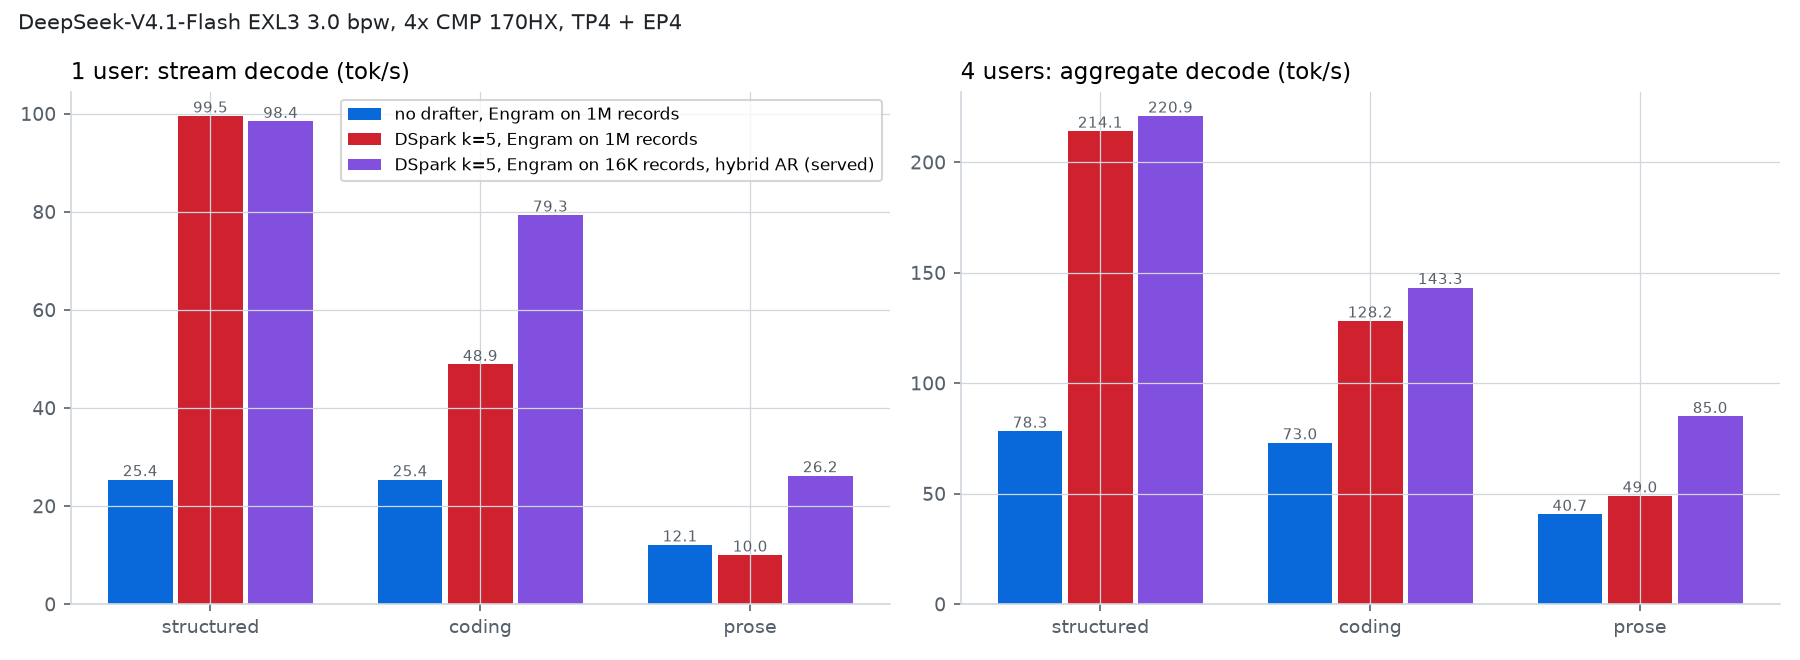

The served configuration is DSpark k=5, the Engram tables on a ZFS dataset with `recordsize=16K`, and vLLM custom all-reduce for messages below 128 KiB. The first configuration (Engram on the default `recordsize=1M`, NCCL only) gave 48.9 tok/s on code, 10.0 on prose and 110–173 tok/s prefill.

```
docker pull ghcr.io/pixelml/club-170hx@sha256:0be9dfdf9fb83a04029108a410236563a9463accd91af010324498ab5f401f5c
```

In [1]:
# --- Status cell ---
import os
EXPERIMENT = "2026-10-03-deepseek-v4.1-flash-exl3-4card-tp4ep4-dspark-vllm"
RESULTS_DIR = "../results/" + EXPERIMENT
RECEIPTS = RESULTS_DIR + "/receipts"
LIVE = False  # True sends the final request to the endpoint in DSV41_URL (an OpenAI-compatible /v1 base)
ENDPOINT_ENV_VAR = "DSV41_URL"
print("LIVE =", LIVE, "| receipts:", RECEIPTS)

LIVE = False | receipts: ../results/2026-10-03-deepseek-v4.1-flash-exl3-4card-tp4ep4-dspark-vllm/receipts


In [2]:
# --- Helpers: receipts, tables, chart style ---
import json, csv, statistics
from IPython.display import display, Markdown
import matplotlib
import matplotlib.pyplot as plt

def receipt(*parts):
    with open("/".join([RECEIPTS, *parts])) as f:
        return json.load(f)

def has(*parts):
    return os.path.exists("/".join([RECEIPTS, *parts]))

def table(header, rows):
    out = ["| " + " | ".join(header) + " |", "|" + "|".join("---:" if i else "---" for i in range(len(header))) + "|"]
    out += ["| " + " | ".join(str(c) for c in r) + " |" for r in rows]
    display(Markdown("\n".join(out)))

INK, INK2, GRID = "#1f2328", "#57606a", "#d0d7de"
S = ["#0969da", "#cf222e", "#8250df", "#1a7f37", "#9a6700"]
matplotlib.rcParams.update({"axes.edgecolor": GRID, "axes.labelcolor": INK, "xtick.color": INK2, "ytick.color": INK2,
                            "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.spines.top": False,
                            "axes.spines.right": False, "font.size": 9})

def label_bars(ax, bars, fmt="{:.1f}"):
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(), fmt.format(b.get_height()), ha="center", va="bottom", color=INK2, fontsize=7)

PROMPTS = ("structured", "coding", "prose")
def decode(v, p, c):
    if not has(v, f"decode-{p}-c{c}.json"):
        return None
    r = receipt(v, f"decode-{p}-c{c}.json")
    return {"tok_s": r.get("tok_s_median") or 0.0, "agg": r.get("aggregate_tok_s_median") or 0.0,
            "acc": r.get("accepted_per_step_median")}
def fmt(x, key="tok_s"):
    return "–" if x is None or x.get(key) is None else f"{x[key]:.1f}"

## 1. TL;DR

- **Measured:** the model runs on four 64 GiB cards with tensor parallelism 4 and expert parallelism 4. Each card holds 96 whole routed experts and a copy of the shared expert. The weights use 54.4 GiB per card with the DSpark layers.
- **Measured:** five greedy known-answer prompts pass in every configuration that we checked. The drafter does not change the edit reply.
- **Measured:** DSpark k=5 (the checkpoint's own MTP layers) gives 98–101 tok/s on structured text for one user. k=10 is slower (55.5). DSpark only accepts multiples of 5, so k=7 is not possible.
- **Measured:** prose and prefill depend on the Engram tables. Each prompt token reads 48 rows of 264 bytes from a 189 GiB table. On ZFS `recordsize=1M`, each missed row reads 1 MB. A dataset with `recordsize=16K` makes prefill 3–5× faster and prose 3× faster (section 3).
- **Measured:** vLLM custom all-reduce over PCIe peer-to-peer helps one user on code (+24%) but slows four users (−22% to −29%). A 128 KiB size limit keeps both gains (section 4).
- **Untested:** a 4-bit Engram table pinned in RAM (103 GiB). It does not fit on the one NUMA node that the server container uses (section 5).

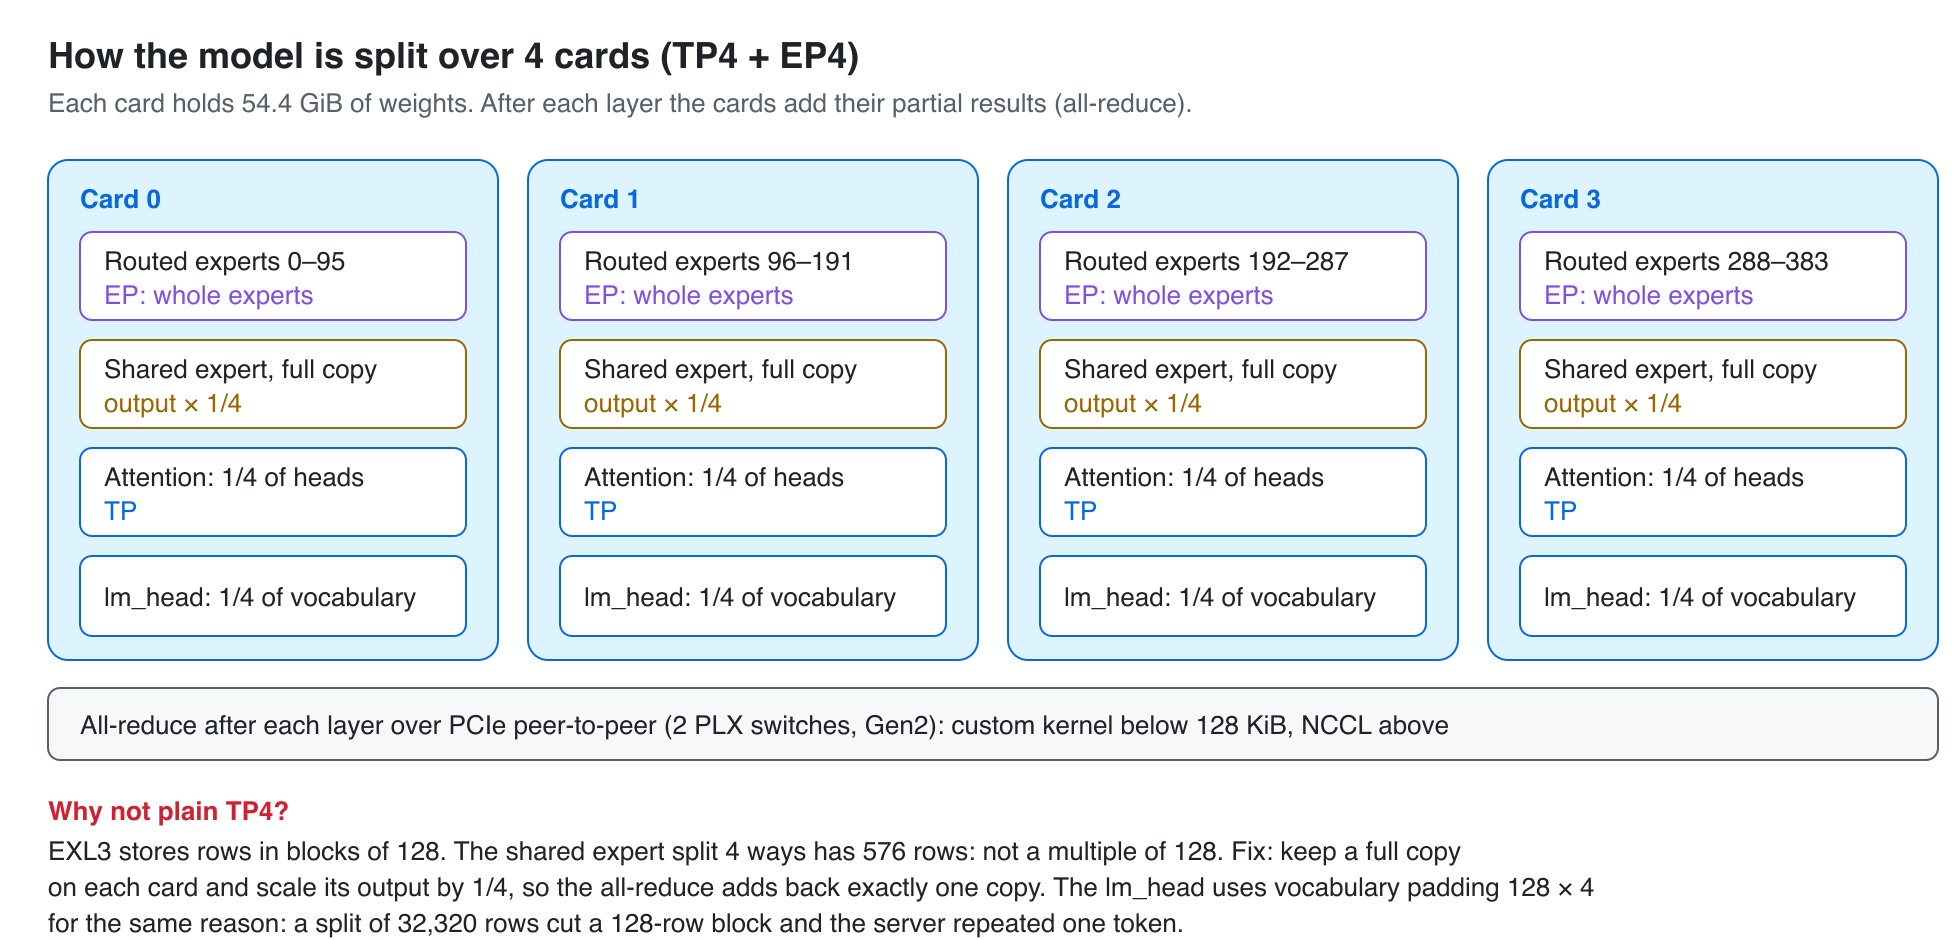

In [3]:
pins = {
    "served image": "ghcr.io/pixelml/club-170hx@sha256:0be9dfdf9fb83a04029108a410236563a9463accd91af010324498ab5f401f5c",
    "first image (Engram on recordsize=1M, NCCL)": "ghcr.io/pixelml/club-170hx@sha256:ffba0e15b5295204a3860fae7ba93fd70fe94d824f79baa1340ab71fa1f451f8",
    "base image": "ghcr.io/pixelml/club-170hx@sha256:75683c4813efaabcc1a96ee610a96a74336677c4a8776b79b01abd83ff3c0c7b (0xSero/dsv41-flash-offload @ 2e9da5ecdab37c232c2da887e25c33a99da738d3, docker/Dockerfile, --build-arg TORCH_CUDA_ARCH_LIST=8.0)",
    "base recipe pins": "lazymio/vllm-backport@sha256:349690323ab9aba712111529ed1ca60730199205d8202f67895ffde85b451be3; Tokha233 a100-turbo fae324ae62ac5cef31b7d38f5d369618e1cae1fa; exllamav3 5be886578ec80324c2c715269387be2058724b6e; vllm-exl3 d3cfd394920360d69f820d2dc96f8292a9e10283",
    "our changes": "results/2026-10-03-deepseek-v4.1-flash-exl3-4card-tp4ep4-dspark-vllm/build (Dockerfile, 5 patched files, launch.sh; diffs in build/patches)",
    "EXL3 checkpoint": "Mia-AiLab/DeepSeek-V4.1-Flash-EXL3-3.0bpw @ c5534b90602b4090980a1c3ded1eb3b4d99a38d5 (MIT)",
    "Engram tables": "deepseek-ai/DeepSeek-V4.1-Flash @ 2cba9e42aa026125f3ed06c6d98c1db82f7ca027, shards 47-48 (MIT), on a ZFS dataset with recordsize=16K",
    "pack": "built by the base image: docker run ... <base image> prepare (overlay pack DSV41-EXL3-3090-D010)",
    "drafter": "DSpark from the checkpoint's mtp.0-2 layers (4 bpw), num_speculative_tokens 5",
    "all-reduce": "custom all-reduce on PCIe P2P below 131,072 bytes, NCCL above (CUSTOM_AR=1, VLLM_CUSTOM_AR_MAX_BYTES=131072, PYTORCH_CUDA_ALLOC_CONF=expandable_segments:False)",
    "driver": "NVIDIA 615.71.09 open + PixelML/cmpunlocker tag cmp170hx-plx-p2p-2026-10-02 = 6ca4da72f078553d37089ee741cd128aa7804504 (64 GiB unlock, BAR1 peer-to-peer)",
    "host": "Proxmox VE 9.2, kernel 7.0.2-6-pve; server in a privileged LXC sharing the host driver, pinned to one NUMA node",
    "topology": "4 cards, PCIe Gen2 behind two PLX switches: three x16, one x8 during these runs; 140 W power cap",
    "context": "65,536 tokens, fp8 KV, 4 sequences; KV pool 263,972 tokens with DSpark k=5",
}
table(["pin", "value"], pins.items())

| pin | value |
|---|---:|
| served image | ghcr.io/pixelml/club-170hx@sha256:0be9dfdf9fb83a04029108a410236563a9463accd91af010324498ab5f401f5c |
| first image (Engram on recordsize=1M, NCCL) | ghcr.io/pixelml/club-170hx@sha256:ffba0e15b5295204a3860fae7ba93fd70fe94d824f79baa1340ab71fa1f451f8 |
| base image | ghcr.io/pixelml/club-170hx@sha256:75683c4813efaabcc1a96ee610a96a74336677c4a8776b79b01abd83ff3c0c7b (0xSero/dsv41-flash-offload @ 2e9da5ecdab37c232c2da887e25c33a99da738d3, docker/Dockerfile, --build-arg TORCH_CUDA_ARCH_LIST=8.0) |
| base recipe pins | lazymio/vllm-backport@sha256:349690323ab9aba712111529ed1ca60730199205d8202f67895ffde85b451be3; Tokha233 a100-turbo fae324ae62ac5cef31b7d38f5d369618e1cae1fa; exllamav3 5be886578ec80324c2c715269387be2058724b6e; vllm-exl3 d3cfd394920360d69f820d2dc96f8292a9e10283 |
| our changes | results/2026-10-03-deepseek-v4.1-flash-exl3-4card-tp4ep4-dspark-vllm/build (Dockerfile, 5 patched files, launch.sh; diffs in build/patches) |
| EXL3 checkpoint | Mia-AiLab/DeepSeek-V4.1-Flash-EXL3-3.0bpw @ c5534b90602b4090980a1c3ded1eb3b4d99a38d5 (MIT) |
| Engram tables | deepseek-ai/DeepSeek-V4.1-Flash @ 2cba9e42aa026125f3ed06c6d98c1db82f7ca027, shards 47-48 (MIT), on a ZFS dataset with recordsize=16K |
| pack | built by the base image: docker run ... <base image> prepare (overlay pack DSV41-EXL3-3090-D010) |
| drafter | DSpark from the checkpoint's mtp.0-2 layers (4 bpw), num_speculative_tokens 5 |
| all-reduce | custom all-reduce on PCIe P2P below 131,072 bytes, NCCL above (CUSTOM_AR=1, VLLM_CUSTOM_AR_MAX_BYTES=131072, PYTORCH_CUDA_ALLOC_CONF=expandable_segments:False) |
| driver | NVIDIA 615.71.09 open + PixelML/cmpunlocker tag cmp170hx-plx-p2p-2026-10-02 = 6ca4da72f078553d37089ee741cd128aa7804504 (64 GiB unlock, BAR1 peer-to-peer) |
| host | Proxmox VE 9.2, kernel 7.0.2-6-pve; server in a privileged LXC sharing the host driver, pinned to one NUMA node |
| topology | 4 cards, PCIe Gen2 behind two PLX switches: three x16, one x8 during these runs; 140 W power cap |
| context | 65,536 tokens, fp8 KV, 4 sequences; KV pool 263,972 tokens with DSpark k=5 |

## 2. Decode (measured)

Protocol: `bench_decode.py` (MiaAI-Lab prompts), T=0, 400 tokens, median of 3 runs, through the OpenAI API. Generated tokens come from the final usage object. One server boot per row. Prose changes from boot to boot by up to ±20%, because its speed depends on which Engram rows are in the page cache.

In [4]:
VARIANTS = [
    ("no-drafter", "no drafter, 1M, NCCL"),
    ("dspark-k5", "k=5, 1M, NCCL"),
    ("dspark-k10", "k=10, 1M (half cached), NCCL"),
    ("dspark-k5-1m-customar", "k=5, 1M, custom AR"),
    ("dspark-k5-1m-singlelookup", "k=5, 1M, NCCL, one-rank lookup"),
    ("dspark-k5-16k-nccl", "k=5, 16K, NCCL"),
    ("dspark-k5-16k-customar", "k=5, 16K, custom AR"),
    ("dspark-k5-16k-hybrid", "k=5, 16K, hybrid AR (served)"),
    ("dspark-k5-4k-hybrid", "k=5, 4K, hybrid AR"),
]
rows = []
for k, lab in VARIANTS:
    one = [decode(k, p, 1) for p in PROMPTS]
    four = [decode(k, p, 4) for p in PROMPTS]
    rows.append([lab] + [fmt(x) for x in one] + [fmt(x, "agg") for x in four] + [fmt(one[0], "acc"), fmt(one[1], "acc")])
table(["configuration", "1 user struct", "code", "prose", "4 users agg struct", "code", "prose", "acc/step struct", "acc/step code"], rows)

| configuration | 1 user struct | code | prose | 4 users agg struct | code | prose | acc/step struct | acc/step code |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| no drafter, 1M, NCCL | 25.4 | 25.4 | 12.1 | 78.3 | 73.0 | 40.7 | – | – |
| k=5, 1M, NCCL | 99.5 | 48.9 | 10.0 | 214.1 | 128.2 | 49.0 | 5.0 | 3.7 |
| k=10, 1M (half cached), NCCL | 55.5 | 53.3 | 24.7 | 45.0 | 40.3 | 23.3 | 3.9 | 3.7 |
| k=5, 1M, custom AR | 98.6 | 67.9 | – | – | – | – | 5.0 | 3.7 |
| k=5, 1M, NCCL, one-rank lookup | 100.6 | 52.1 | 11.6 | – | – | – | 5.0 | 3.6 |
| k=5, 16K, NCCL | 100.6 | 63.8 | 30.3 | 219.3 | 142.6 | 97.2 | 5.0 | 3.7 |
| k=5, 16K, custom AR | 98.6 | 75.6 | 35.3 | 171.3 | 100.9 | 74.5 | 5.0 | 3.7 |
| k=5, 16K, hybrid AR (served) | 98.4 | 79.3 | 26.2 | 220.9 | 143.3 | 85.0 | 5.0 | 4.0 |
| k=5, 4K, hybrid AR | 98.5 | 75.4 | 37.5 | – | – | – | 5.0 | 3.7 |

### 2.1 Headline chart

Three steps: no drafter, DSpark k=5 on the first storage layout, and the served configuration. The chart goes to `assets/charts/`.

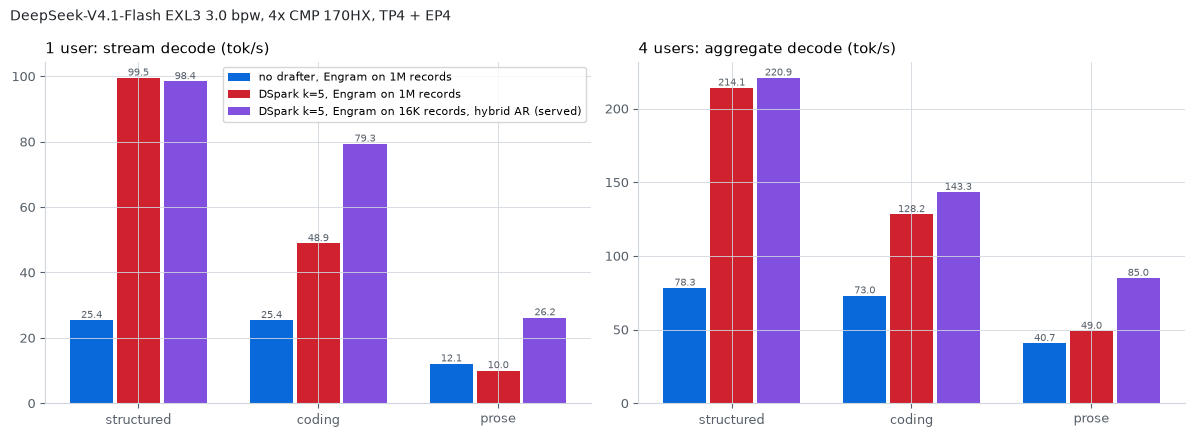

In [5]:
SHOW = [("no-drafter", "no drafter, Engram on 1M records"), ("dspark-k5", "DSpark k=5, Engram on 1M records"),
        ("dspark-k5-16k-hybrid", "DSpark k=5, Engram on 16K records, hybrid AR (served)")]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for ax, c, key, title in ((axes[0], 1, "tok_s", "1 user: stream decode (tok/s)"), (axes[1], 4, "agg", "4 users: aggregate decode (tok/s)")):
    w = 0.26
    for i, (k, lab) in enumerate(SHOW):
        bars = ax.bar([j + (i - 1) * w for j in range(3)], [decode(k, p, c)[key] for p in PROMPTS], w * 0.92, color=S[i], label=lab)
        label_bars(ax, bars)
    ax.set_xticks(range(3), PROMPTS); ax.set_title(title, loc="left")
axes[0].legend(fontsize=8)
fig.suptitle("DeepSeek-V4.1-Flash EXL3 3.0 bpw, 4x CMP 170HX, TP4 + EP4", x=0.01, ha="left", fontsize=10, color=INK)
fig.tight_layout()
os.makedirs("../assets/charts", exist_ok=True)
fig.savefig(f"../assets/charts/{EXPERIMENT}.png", dpi=150); fig.savefig(f"../assets/charts/{EXPERIMENT}.svg")
plt.show()

## 3. Prefill and the Engram tables (measured)

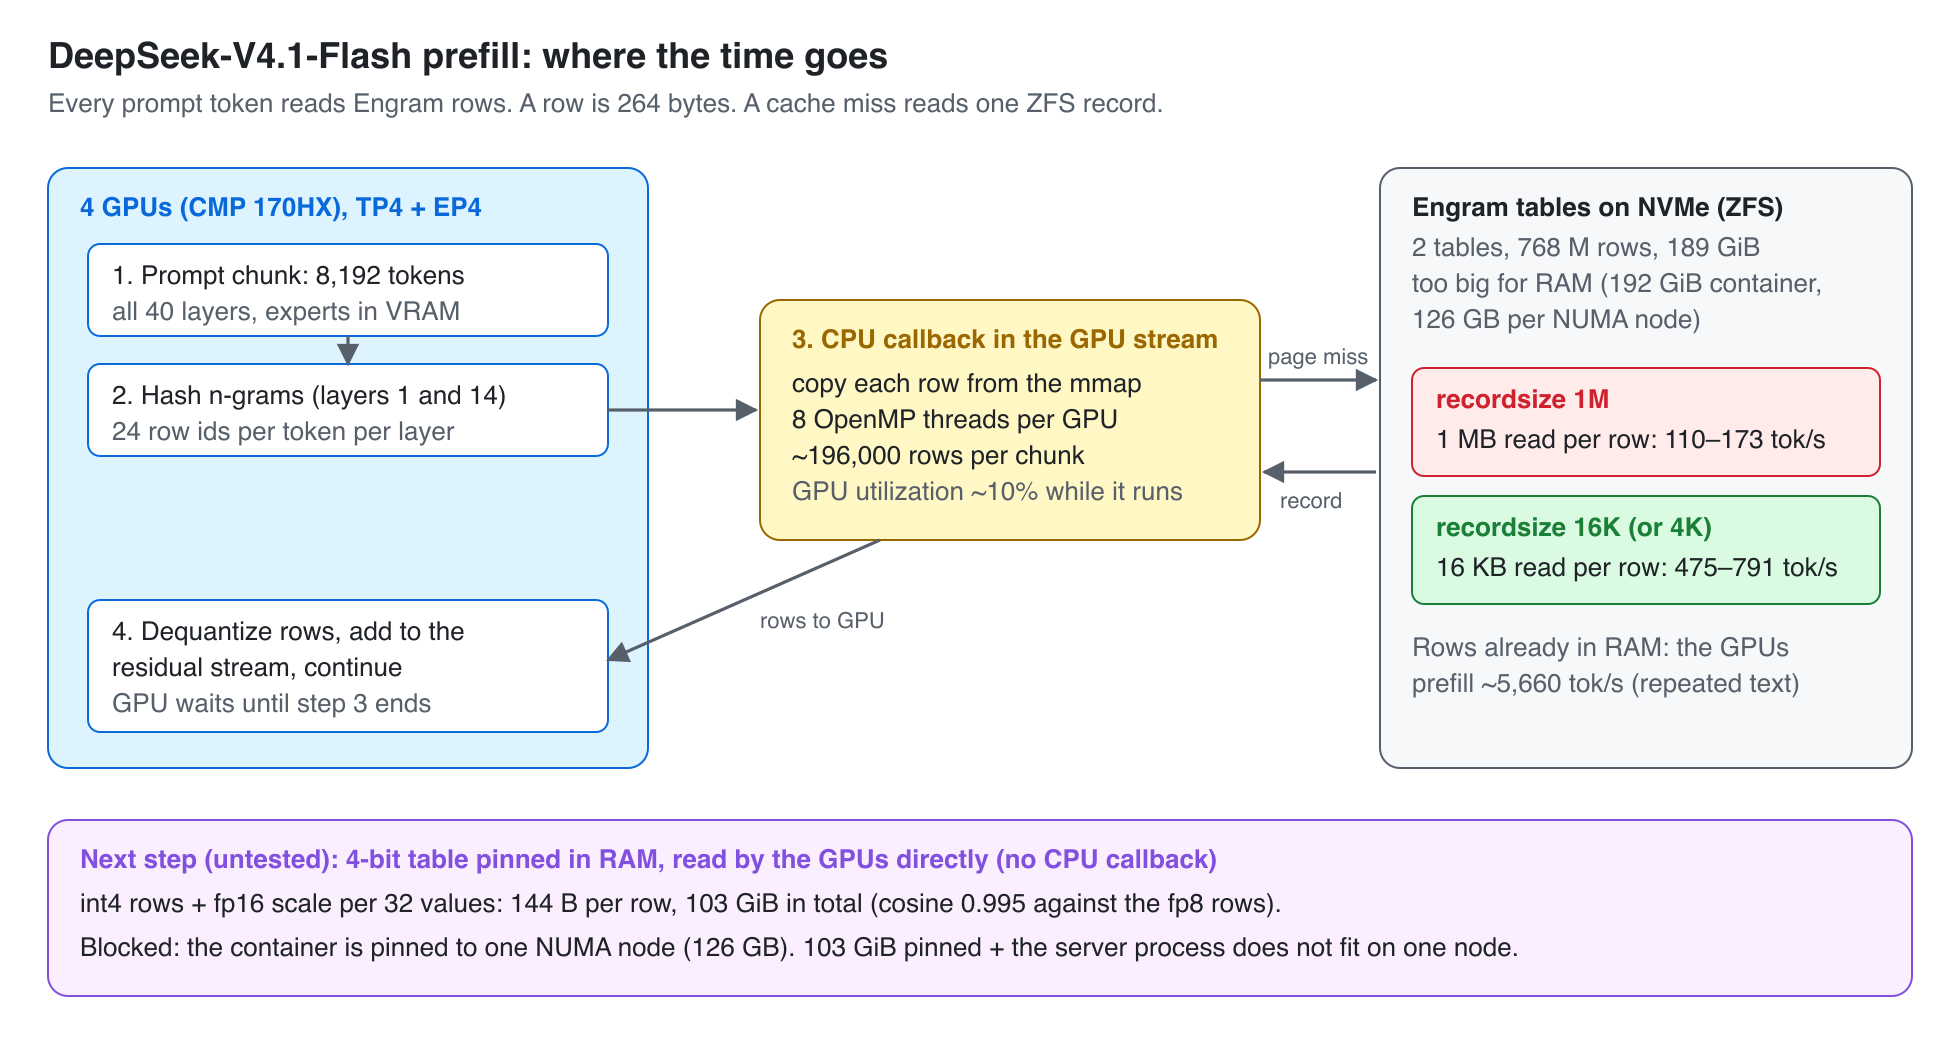

DeepSeek-V4.1 has two Engram layers (1 and 14). For each prompt token, each layer reads 24 hashed rows from its table. The two tables have 768 million rows of 264 bytes (189 GiB). The tables do not fit in RAM here, so the recipe reads them through a memory map. A CPU callback in the GPU stream copies the rows. The GPU waits for it: GPU utilization was about 10% during cold prefill.

When the rows are already in RAM (a prompt with repeated text), the four GPUs prefill about 5,660 tok/s (a server log line; not in the receipts). Thus the storage path sets the prefill speed. On ZFS, a cache miss reads one full record. The default `recordsize=1M` reads 1 MB for each 264-byte row. A copy of the tables on a dataset with `recordsize=16K` reads 16 KB. Use `dd` for the copy: `cp` can clone the ZFS blocks, and cloned blocks keep their 1M record size.

Protocol: unique real text with a nonce (no prefix-cache hits), `max_tokens=1`, one request at a time.

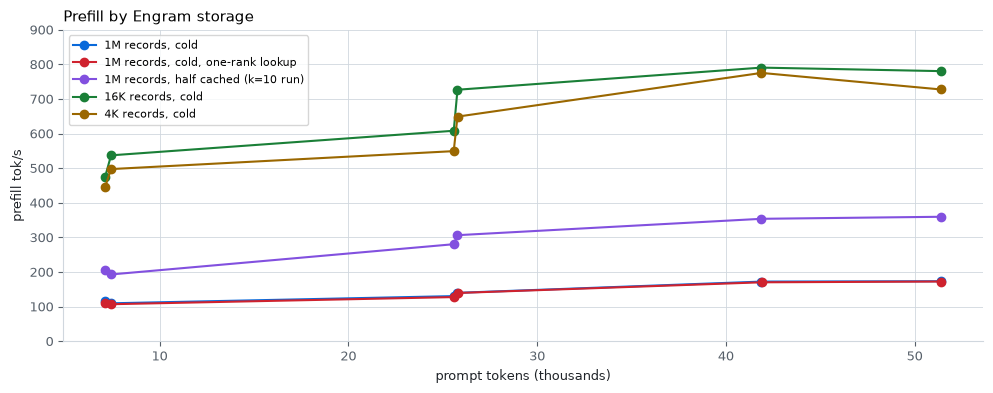

| Engram storage | prefill tok/s, 7k–51k tokens |
|---|---:|
| 1M records, cold | 110–173 |
| 1M records, cold, one-rank lookup | 107–173 |
| 1M records, half cached (k=10 run) | 193–360 |
| 16K records, cold | 475–791 |
| 4K records, cold | 446–775 |

| prompt tokens | TTFT s | decode tok/s (no drafter, 1M) |
|---|---:|---:|
| 916 | 2.4 | 13.4 |
| 7531 | 48.2 | 15.4 |
| 28282 | 140.2 | 14.4 |
| 45476 | 145.5 | 14.3 |

In [6]:
PF = [("no-drafter", "1M records, cold"), ("dspark-k5-1m-singlelookup", "1M records, cold, one-rank lookup"),
      ("dspark-k10", "1M records, half cached (k=10 run)"), ("dspark-k5-16k-customar", "16K records, cold"), ("dspark-k5-4k-hybrid", "4K records, cold")]
fig, ax = plt.subplots(figsize=(10, 4.0))
for i, (k, lab) in enumerate(PF):
    r = sorted(receipt(k, "prefill.json")["results"], key=lambda x: x["prompt_tokens"])
    ax.plot([x["prompt_tokens"] / 1000 for x in r], [x["prefill_tok_s"] for x in r], marker="o", color=S[i], label=lab)
ax.set_xlabel("prompt tokens (thousands)"); ax.set_ylabel("prefill tok/s"); ax.set_ylim(0, 900)
ax.set_title("Prefill by Engram storage", loc="left"); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(f"../assets/charts/{EXPERIMENT}-prefill.png", dpi=150); plt.show()
rows = []
for k, lab in PF:
    v = [x["prefill_tok_s"] for x in receipt(k, "prefill.json")["results"]]
    rows.append([lab, f"{min(v):.0f}–{max(v):.0f}"])
table(["Engram storage", "prefill tok/s, 7k–51k tokens"], rows)
lc = receipt("no-drafter", "longdecode.json")["results"]
table(["prompt tokens", "TTFT s", "decode tok/s (no drafter, 1M)"], [[r["prompt_tokens"], f"{r['ttft_s']:.1f}", f"{r['decode_tok_s']:.1f}"] for r in lc])

## 4. All-reduce: NCCL, custom, or both (measured)

Stock vLLM turns off its custom all-reduce on more than two PCIe GPUs. These cards have working BAR1 peer-to-peer, so the patch `custom_all_reduce.patch` lets it run (`VLLM_FORCE_CUSTOM_AR_PCIE=1`). It fails at start-up with `custom_all_reduce.cuh:164 'invalid argument'` unless `PYTORCH_CUDA_ALLOC_CONF=expandable_segments:False` is set (the CUDA IPC handles need the legacy allocator).

One user sends about 61 KB per all-reduce (6 tokens × 5,120 × 2 bytes). Four users send about 245 KB. The custom kernel is faster for the small message and slower for the large one. `VLLM_CUSTOM_AR_MAX_BYTES=131072` uses the custom kernel below 128 KiB and NCCL above.

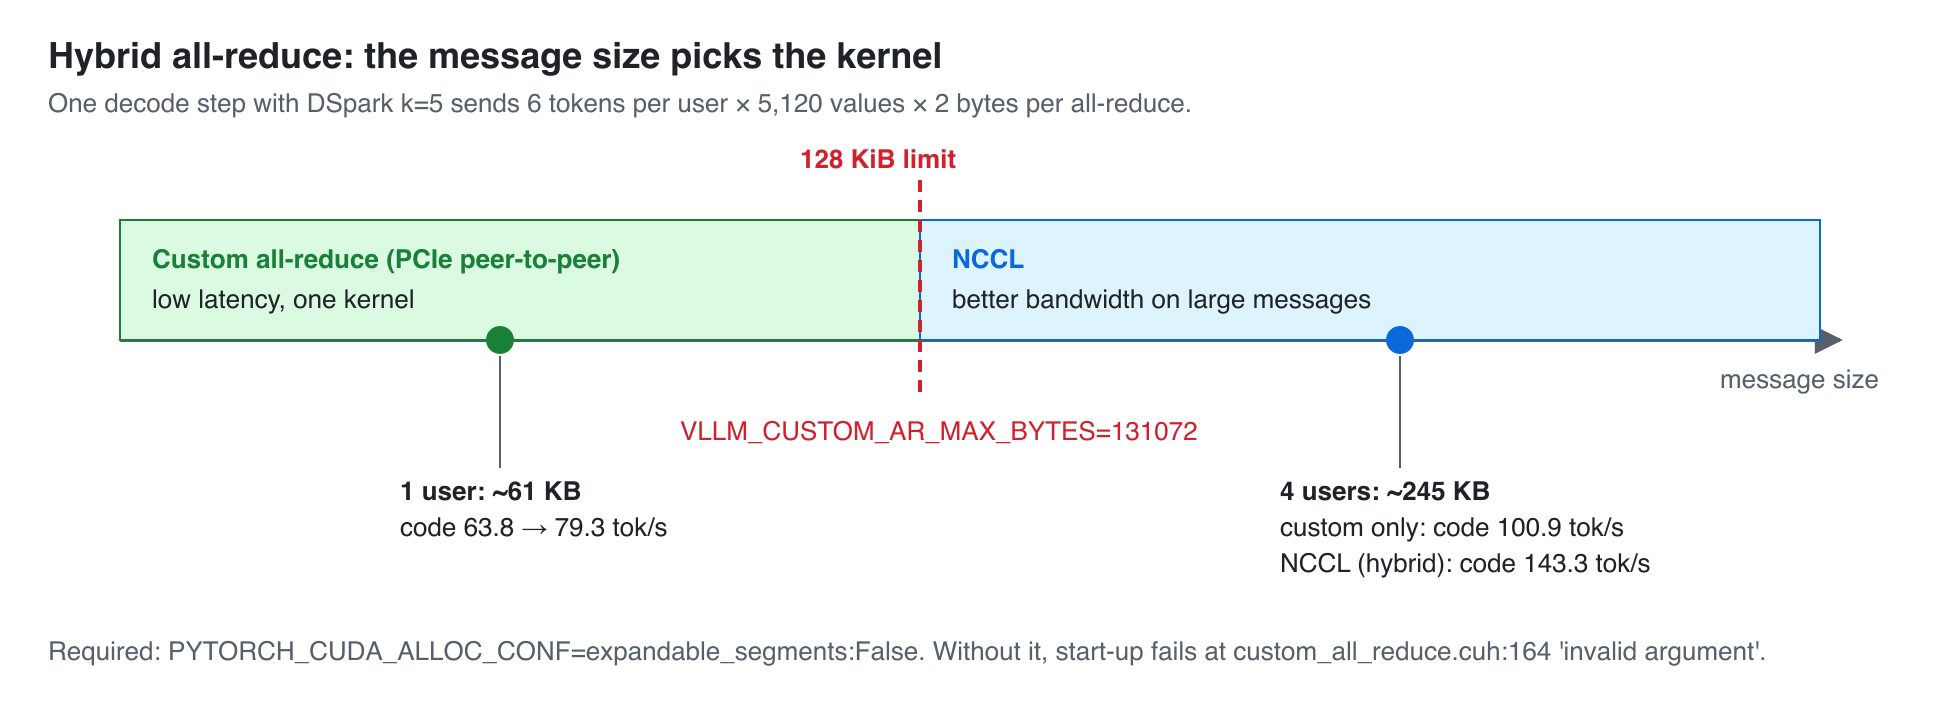

In [7]:
AR = [("dspark-k5-16k-nccl", "NCCL"), ("dspark-k5-16k-customar", "custom AR"), ("dspark-k5-16k-hybrid", "hybrid, < 128 KiB custom (served)")]
rows = []
for k, lab in AR:
    rows.append([lab] + [fmt(decode(k, p, 1)) for p in PROMPTS] + [fmt(decode(k, p, 4), "agg") for p in PROMPTS])
table(["all-reduce (Engram on 16K records)", "1 user struct", "code", "prose", "4 users agg struct", "code", "prose"], rows)

| all-reduce (Engram on 16K records) | 1 user struct | code | prose | 4 users agg struct | code | prose |
|---|---:|---:|---:|---:|---:|---:|
| NCCL | 100.6 | 63.8 | 30.3 | 219.3 | 142.6 | 97.2 |
| custom AR | 98.6 | 75.6 | 35.3 | 171.3 | 100.9 | 74.5 |
| hybrid, < 128 KiB custom (served) | 98.4 | 79.3 | 26.2 | 220.9 | 143.3 | 85.0 |

## 5. What did not help (measured), and what is next

- **TP4 alone fails.** EXL3 stores rows in blocks of 128. The shared expert split four ways has 576 rows. Fix: expert parallelism for the routed experts, and a replicated shared expert with its output scaled by 1/4 before the all-reduce (exact, because 4 is a power of two).
- **TP2 × PP2 fails.** On stage 1, the KV allocation refers to compressor caches of stage-0 layers 2, 8 and 14.
- **An lm_head split of 32,320 rows per card gives wrong output.** The server repeats one token. The bad token ids are at local row 32,256 of each card, the edge of a 128-row Hadamard block. Fix: build the head with vocabulary padding 128 × 4.
- **DSpark k=10** accepts fewer drafts per step and is slower than k=5, mostly with four users.
- **A one-rank Engram lookup** (card 0 reads, NCCL copies the bytes to the other cards) is correct but not faster: 107–173 tok/s prefill. The four copies of the lookup do not limit the speed. The latency of each lookup does.
- **4K records** give the same result as 16K records. The read size no longer limits the speed.
- **Next (untested): 4-bit Engram in pinned RAM.** Int4 rows with an fp16 scale for each 32 values use 144 bytes per row, 103 GiB in total (cosine 0.995 against the fp8 rows, measured on 4,096 rows). The GPUs then read the rows directly, with no CPU callback. The server container is pinned to one NUMA node with 126 GB. The pinned table and the server process do not fit on that node: the first start-up stopped with an out-of-memory kill of one worker.

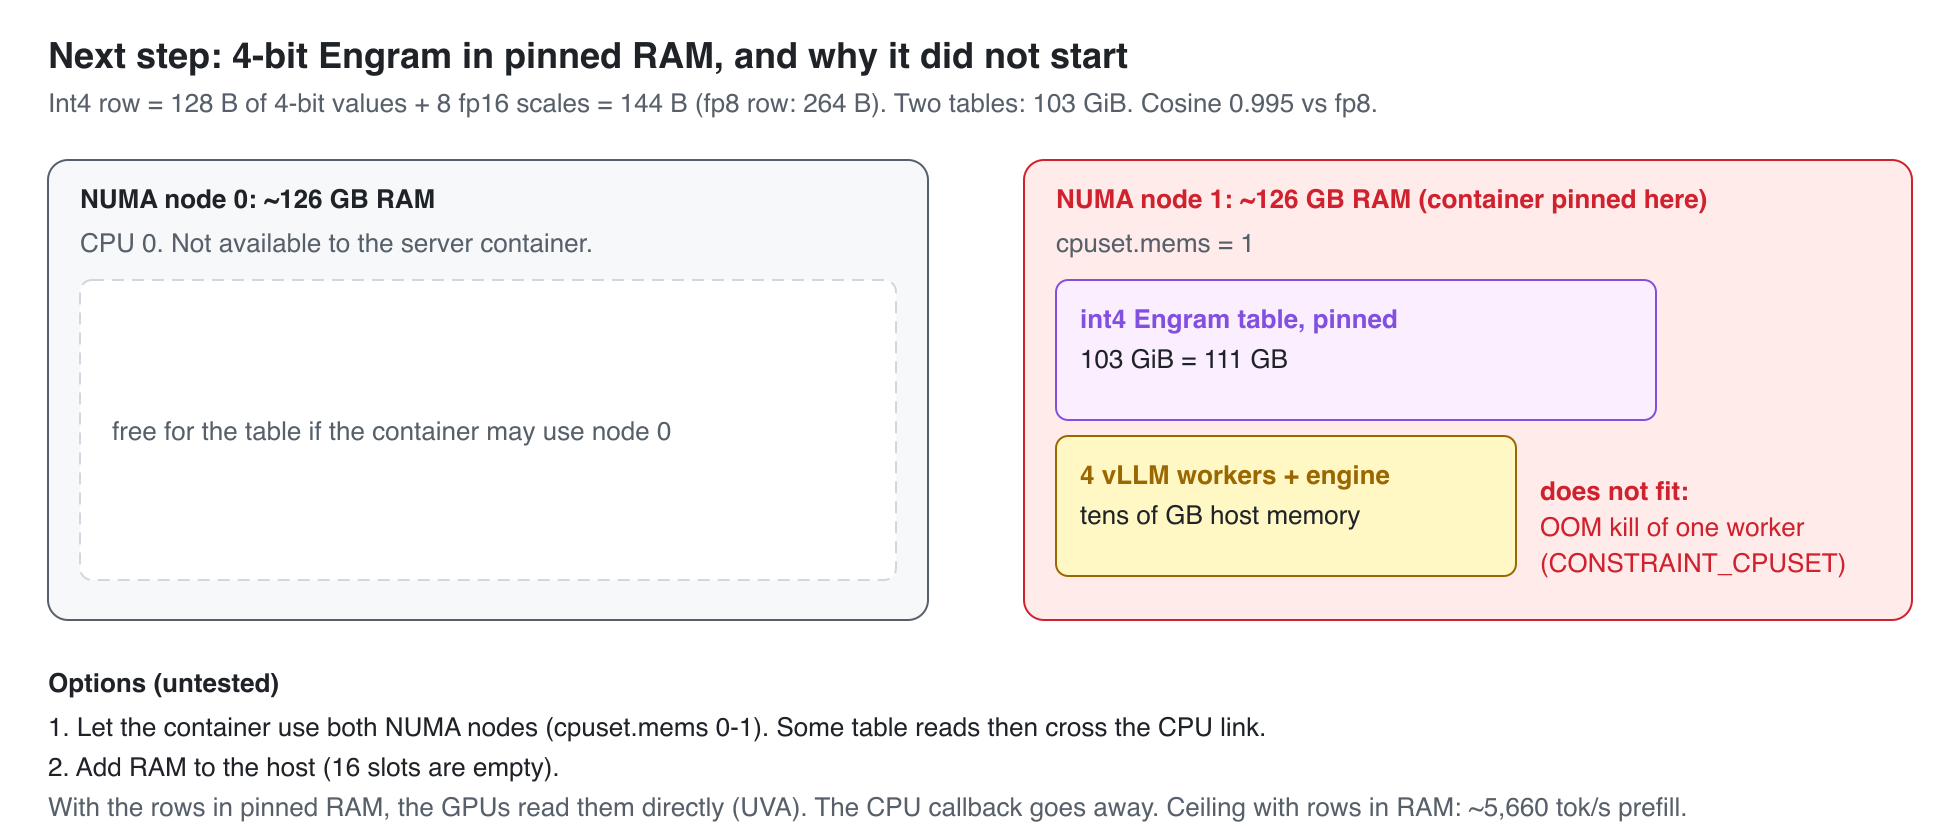

## 6. Thermals

Peak core temperature and power from 2 s `nvidia-smi` samples, for the first three runs (the later runs did not record telemetry). The stop rule in this repository is 80 °C core.

In [8]:
def telemetry(k):
    rows = list(csv.reader(open(f"{RECEIPTS}/{k}/telemetry.csv"), skipinitialspace=True))[1:]
    temps, power = [], []
    for r in rows:
        try:
            temps.append(float(r[2])); power.append(float(r[3].split()[0]))
        except (ValueError, IndexError):
            pass
    return temps, power
rows = []
for k, lab in (("no-drafter", "no drafter"), ("dspark-k5", "DSpark k=5"), ("dspark-k10", "DSpark k=10")):
    t, p = telemetry(k)
    rows.append([lab, f"{max(t):.0f}", f"{statistics.mean(p):.0f}", f"{max(p):.0f}"])
table(["run", "peak core °C", "mean W per card", "peak sampled W (instantaneous; cap 140 W)"], rows)
c = receipt("correctness.json")
table(["prompt", "expected", "pass", "reply tokens"], [[r["prompt"][:48], r["expect"], r["pass"], r["completion_tokens"]] for r in c["cases"]])
print(f"{c['correct']}/{c['total']} correct (DSpark k=5, Engram on 1M records); the 16K run also passed 5/5: receipts/dspark-k5-16k-customar/correctness.json")

| run | peak core °C | mean W per card | peak sampled W (instantaneous; cap 140 W) |
|---|---:|---:|---:|
| no drafter | 70 | 64 | 209 |
| DSpark k=5 | 70 | 75 | 186 |
| DSpark k=10 | 70 | 74 | 193 |

| prompt | expected | pass | reply tokens |
|---|---:|---:|---:|
| What is 17 * 23? Answer with the number only. | 391 | True | 21 |
| What is the capital of Australia? One word. | Canberra | True | 20 |
| A train leaves at 09:40 and arrives at 13:15. Ho | 215 | True | 47 |
| Write a Python function is_prime(n). Then state  | RESULT=True | True | 225 |
| Spell the word ELEPHANT backwards, uppercase, no | TNAHPELE | True | 62 |

5/5 correct (DSpark k=5, Engram on 1M records); the 16K run also passed 5/5: receipts/dspark-k5-16k-customar/correctness.json


## 7. Reproduce

Hardware: 4 × CMP 170HX with 65,536 MiB each (64 GiB unlock), forced-air cooling, about 600 GB of disk. The weights do not fit on fewer than four cards.

```bash
# 1. Weights: EXL3 checkpoint and Engram shards 47-48
hf download Mia-AiLab/DeepSeek-V4.1-Flash-EXL3-3.0bpw --revision c5534b90602b4090980a1c3ded1eb3b4d99a38d5 \
  --local-dir /path/to/models/Mia-DeepSeek-V4.1-Flash-EXL3-3.0bpw
hf download deepseek-ai/DeepSeek-V4.1-Flash --revision 2cba9e42aa026125f3ed06c6d98c1db82f7ca027 \
  --include "model-00047-of-00048.safetensors" "model-00048-of-00048.safetensors" "config.json" \
  "model.safetensors.index.json" "inference/engram.py" --local-dir /path/to/models/DeepSeek-V4.1-Flash-engram

# 2. Engram tables on small ZFS records (skip on ext4/xfs). Use dd: cp can clone blocks.
zfs create -o recordsize=16K -o compression=off -o atime=off <pool>/engram16k
for s in 47 48; do
  dd if=/path/to/models/DeepSeek-V4.1-Flash-engram/model-000$s-of-00048.safetensors \
     of=/<pool>/engram16k/model-000$s-of-00048.safetensors bs=16M status=progress
done

# 3. Overlay pack (the base image's prepare step; one card)
docker run --rm --gpus '"device=0"' -v /path/to/models:/models ghcr.io/pixelml/club-170hx@sha256:75683c4813efaabcc1a96ee610a96a74336677c4a8776b79b01abd83ff3c0c7b prepare

# 4. Serve: TP4 + EP4, DSpark k=5, hybrid all-reduce (image defaults), port 8040
docker run -d --name dsv41 --gpus all --ulimit memlock=-1 --shm-size 16g -p 8040:8040 \
  -v /path/to/models:/models:ro \
  -v /<pool>/engram16k/model-00047-of-00048.safetensors:/models/DeepSeek-V4.1-Flash-engram/model-00047-of-00048.safetensors:ro \
  -v /<pool>/engram16k/model-00048-of-00048.safetensors:/models/DeepSeek-V4.1-Flash-engram/model-00048-of-00048.safetensors:ro \
  ghcr.io/pixelml/club-170hx@sha256:0be9dfdf9fb83a04029108a410236563a9463accd91af010324498ab5f401f5c \
  --speculative-config '{"method":"dspark","num_speculative_tokens":5}'
```

`build/launch.sh` holds every serve argument: `--tensor-parallel-size 4 --enable-expert-parallel --quantization exl3 --max-model-len 65536 --max-num-seqs 4 --max-num-batched-tokens 8192 --kv-cache-dtype fp8 --gpu-memory-utilization 0.94 --no-enable-prefix-caching --language-model-only --tokenizer-mode deepseek_v41`, CUDA graphs for decode sizes 1–24, `DSV41_REPLICATE_SHARED=1`, the disk Engram tier and an empty host-expert plan. The image sets `CUSTOM_AR=1 VLLM_FORCE_CUSTOM_AR_PCIE=1 VLLM_CUSTOM_AR_MAX_BYTES=131072 PYTORCH_CUDA_ALLOC_CONF=expandable_segments:False`. Set `CUSTOM_AR=0` on hosts without GPU peer-to-peer. Power cap: `nvidia-smi -pl 140`. Bench scripts: `bench_decode.py`, `bench_edit.py`, `bench_long.py` in `results/2026-10-03-deepseek-v4.1-flash-exl3-4card-tp4ep4-dspark-vllm/`.

## Try your own prompt

Edit `PROMPT`. With `LIVE = False`, the cell prints the recorded known-answer reply.

In [9]:
PROMPT = "What is 17 * 23? Answer with the number only."
if LIVE:
    import urllib.request
    url = os.environ[ENDPOINT_ENV_VAR]
    body = {"model": "deepseek-v4.1-flash", "messages": [{"role": "user", "content": PROMPT}], "max_tokens": 1500, "temperature": 0}
    req = urllib.request.Request(url + "/chat/completions", json.dumps(body).encode(), {"Content-Type": "application/json"})
    resp = json.load(urllib.request.urlopen(req, timeout=900))
    msg = resp["choices"][0]["message"]
    print("reasoning:", (msg.get("reasoning_content") or msg.get("reasoning") or "")[:400]); print("answer:", msg.get("content")); print(resp["usage"])
else:
    case = receipt("correctness.json")["cases"][0]
    print(case["prompt"], "->", case["content"], "| tokens:", case["completion_tokens"])

What is 17 * 23? Answer with the number only. -> 391 | tokens: 21


<details><summary>Appendix: licences and notes</summary>

- vllm-exl3 is AGPL-3.0 (with Apache-2.0 parts). The patched `exl3.py` is in `build/`. The base recipe is MIT. The checkpoint and the Engram tables are MIT.
- The base recipe is for one 24 GB card with host-offloaded experts. Its entrypoint stops with SIGPIPE (code 141) when it sees more than one GPU. `launch.sh` replaces it.
- One card trained at PCIe Gen2 x8 during these runs. The other three ran at x16.
- `engram_disk.patch` also adds `DSV41_ENGRAM_SINGLE=1` (one-rank lookup). It is off in the image because it did not help (section 5).
</details>